# Descriptive Analysis

In this notebook, we will:
- Load all the cleaned datasets.
- Check for missing values and get basic descriptive statistics.
- Visualize the distributions of key variables such as Happiness Score, GDP, Health, Freedom, and Corruption.
- Compare statistics by region and by year where applicable.


In [3]:
# Import required libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Paths to CSV files

In [6]:
# Set Seaborn style for plots
sns.set(style="whitegrid", context="talk")

# Define the folder with cleaned CSV files
cleaned_folder = "CSVs"

# Load datasets from the cleaned CSVs
df_religious = pd.read_csv(os.path.join(cleaned_folder, "world_religious.csv"))
df_population = pd.read_csv(os.path.join(cleaned_folder, "world_population_and_health.csv"))
df_happiness = pd.read_csv(os.path.join(cleaned_folder, "world_happiness_report_2024.csv"))
df_gdp = pd.read_csv(os.path.join(cleaned_folder, "gdp_long.csv"))
df_cpi = pd.read_csv(os.path.join(cleaned_folder, "CPI2023_global_results_trends.csv"))
df_liberties = pd.read_csv(os.path.join(cleaned_folder, "civil_liberties_score_fh_new.csv"))

# For hdr_general, if needed (assuming it's been cleaned already)
hdr_file = os.path.join(cleaned_folder, "hdr_general.csv")
try:
    df_hdr = pd.read_csv(hdr_file)
except Exception as e:
    df_hdr = None
    print("hdr_general_clean.csv could not be loaded:", e)

# Display first few rows of each dataset for initial exploration
print("World Religious Data:")
print(df_religious.head(), "\n")

print("World Population and Health Data:")
print(df_population.head(), "\n")

print("World Happiness Report Data:")
print(df_happiness.head(), "\n")

print("GDP Data (Long Format):")
print(df_gdp.head(), "\n")

print("CPI Data:")
print(df_cpi.head(), "\n")

print("Civil Liberties Data:")
print(df_liberties.head(), "\n")


World Religious Data:
   Country  Year     Religion      Value
0  Albania  2011        Total  2800138.0
1  Albania  2011      Atheist    69995.0
2  Albania  2011     Catholic   280921.0
3  Albania  2011  Evangelical     3797.0
4  Albania  2011       Muslim  1587608.0 

World Population and Health Data:
       Country  Year  Population country_code  health_exp  life_expect  \
0  Afghanistan  2014    56805036          AFG    9.528878       62.545   
1      Albania  2014   127571863          ALB    6.434511       78.407   
2      Algeria  2014   147582820          DZA    6.547214       75.110   
3      Andorra  2014   133274038          AND    6.773080       72.794   
4       Angola  2014    35838921          AGO    2.434129       60.040   

   maternal_mortality  infant_mortality  neonatal_mortality  \
0               785.0              56.2                43.5   
1                 7.0               8.8                 5.9   
2                86.0              22.0                15.8   

## Checking for Missing Values and Basic Descriptive Statistics


In [7]:
# Function to display missing values and descriptive statistics for a given DataFrame
def data_overview(df, df_name):
    print(f"--- {df_name} ---")
    print("Missing Values:")
    print(df.isnull().sum())
    print("\nDescriptive Statistics:")
    print(df.describe(include="all"))
    print("\n")

# Overview for each dataset
data_overview(df_religious, "World Religious")
data_overview(df_population, "World Population and Health")
data_overview(df_happiness, "World Happiness Report")
data_overview(df_gdp, "GDP (Long Format)")
data_overview(df_cpi, "CPI")
data_overview(df_liberties, "Civil Liberties")
if df_hdr is not None:
    data_overview(df_hdr, "HDR General")


--- World Religious ---
Missing Values:
Country      0
Year         0
Religion    79
Value        0
dtype: int64

Descriptive Statistics:
       Country          Year Religion         Value
count    17431  17431.000000    17352  1.743100e+04
unique     106           NaN      396           NaN
top     Canada           NaN    Total           NaN
freq      1535           NaN     1007           NaN
mean       NaN   2005.033962      NaN  1.695265e+06
std        NaN      4.951340      NaN  1.734961e+07
min        NaN   1995.000000      NaN  0.000000e+00
25%        NaN   2001.000000      NaN  6.495000e+02
50%        NaN   2004.000000      NaN  7.195000e+03
75%        NaN   2011.000000      NaN  1.155210e+05
max        NaN   2012.000000      NaN  1.028610e+09


--- World Population and Health ---
Missing Values:
Country                  0
Year                     0
Population               0
country_code             0
health_exp               0
life_expect              0
maternal_mortality    

## Visualizing Key Variables

In this section, we create visualizations for some key indicators from the datasets.


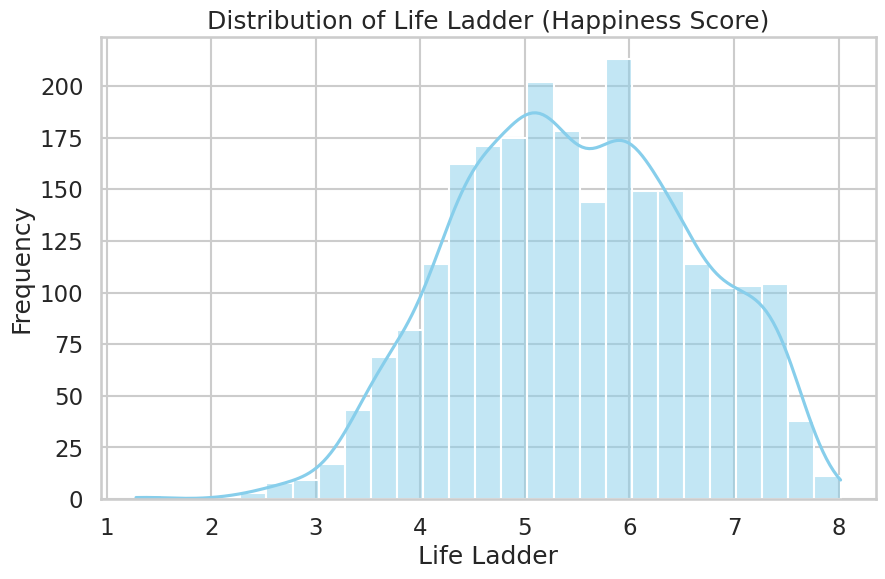

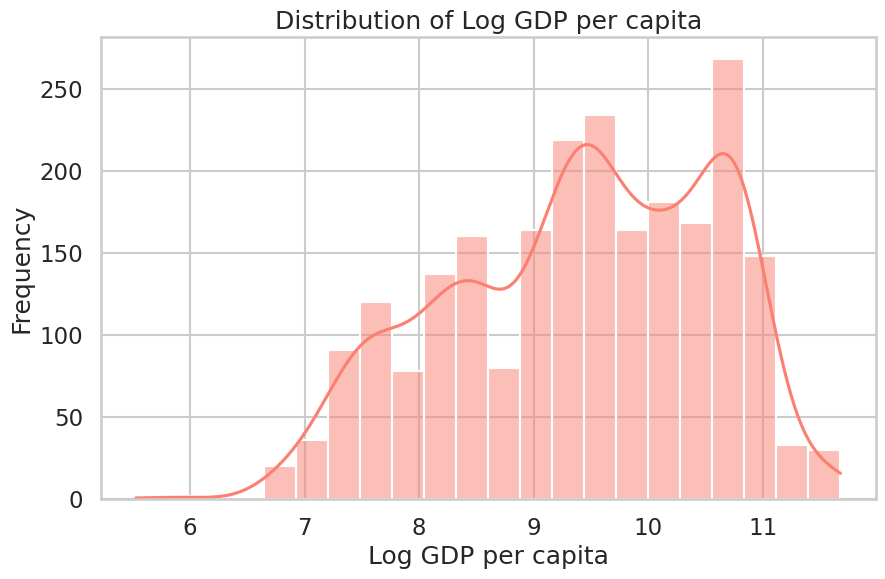

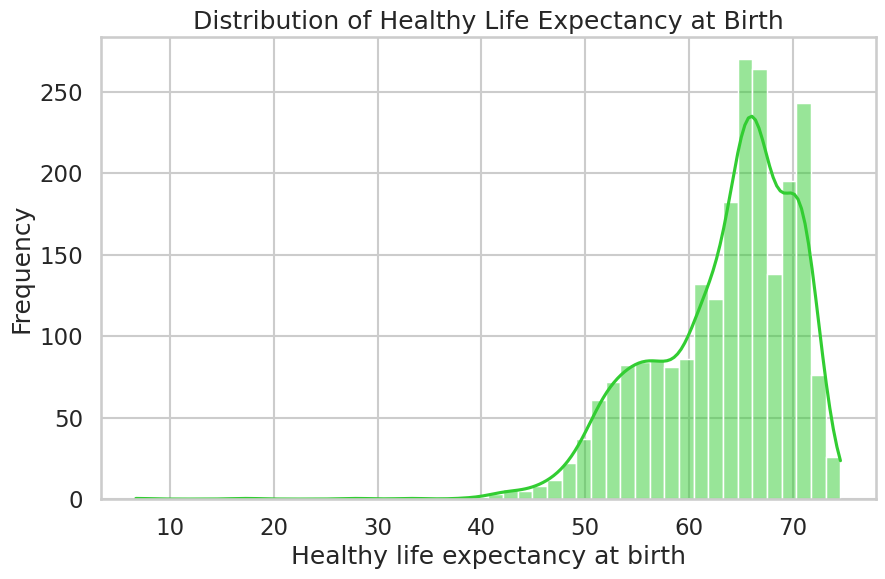

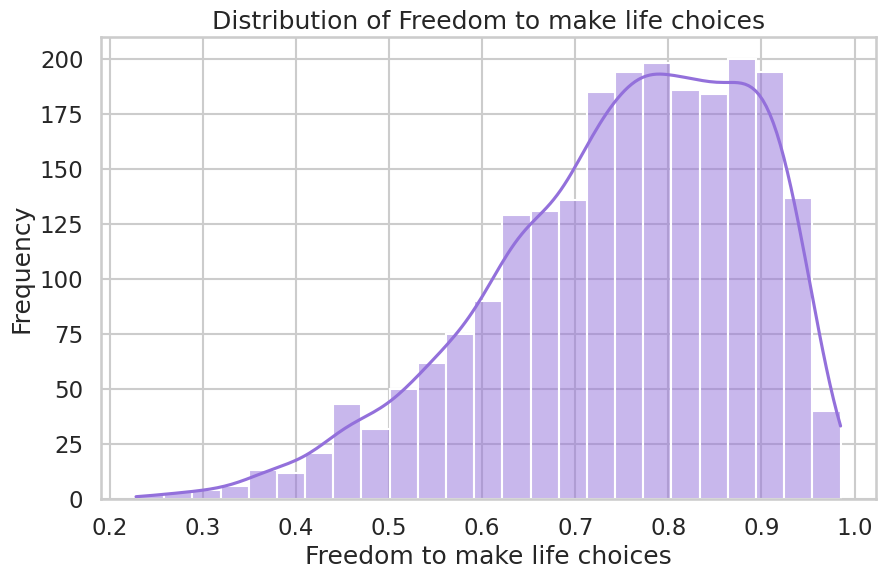

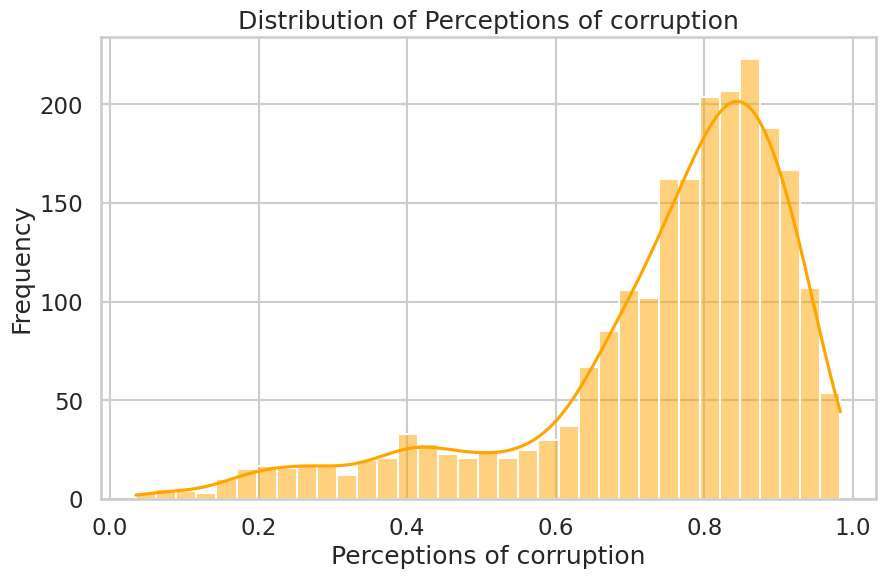

In [8]:
# Example: Distribution of Life Ladder (Happiness Score) from world_happiness_report_2024
plt.figure(figsize=(10, 6))
sns.histplot(df_happiness["Life Ladder"], kde=True, color="skyblue")
plt.title("Distribution of Life Ladder (Happiness Score)")
plt.xlabel("Life Ladder")
plt.ylabel("Frequency")
plt.show()

# Example: Distribution of Log GDP per capita from world_happiness_report_2024
plt.figure(figsize=(10, 6))
sns.histplot(df_happiness["Log GDP per capita"].dropna(), kde=True, color="salmon")
plt.title("Distribution of Log GDP per capita")
plt.xlabel("Log GDP per capita")
plt.ylabel("Frequency")
plt.show()

# Example: Distribution of Healthy Life Expectancy at Birth from world_happiness_report_2024
plt.figure(figsize=(10, 6))
sns.histplot(df_happiness["Healthy life expectancy at birth"].dropna(), kde=True, color="limegreen")
plt.title("Distribution of Healthy Life Expectancy at Birth")
plt.xlabel("Healthy life expectancy at birth")
plt.ylabel("Frequency")
plt.show()

# Example: Distribution of Freedom to make life choices from world_happiness_report_2024
plt.figure(figsize=(10, 6))
sns.histplot(df_happiness["Freedom to make life choices"].dropna(), kde=True, color="mediumpurple")
plt.title("Distribution of Freedom to make life choices")
plt.xlabel("Freedom to make life choices")
plt.ylabel("Frequency")
plt.show()

# Example: Distribution of Perceptions of corruption from world_happiness_report_2024
plt.figure(figsize=(10, 6))
sns.histplot(df_happiness["Perceptions of corruption"].dropna(), kde=True, color="orange")
plt.title("Distribution of Perceptions of corruption")
plt.xlabel("Perceptions of corruption")
plt.ylabel("Frequency")
plt.show()


## Comparing Statistics by Region and Year

Here, you can merge datasets by `Country` (and `Year` where applicable) to compare key metrics (such as GDP, Happiness, and Health) across different regions and time periods.

For example, you might want to merge `df_happiness` with `df_gdp` to see how GDP correlates with Happiness over the years.


Merged dataset (Happiness and GDP) sample:
       Country  year  Life Ladder  Log GDP per capita  Social support  \
0  Afghanistan  2008        3.724               7.350           0.451   
1  Afghanistan  2009        4.402               7.509           0.552   
2  Afghanistan  2010        4.758               7.614           0.539   
3  Afghanistan  2011        3.832               7.581           0.521   
4  Afghanistan  2012        3.783               7.661           0.521   

   Healthy life expectancy at birth  Freedom to make life choices  Generosity  \
0                              50.5                         0.718       0.164   
1                              50.8                         0.679       0.187   
2                              51.1                         0.600       0.118   
3                              51.4                         0.496       0.160   
4                              51.7                         0.531       0.234   

   Perceptions of corruption  P

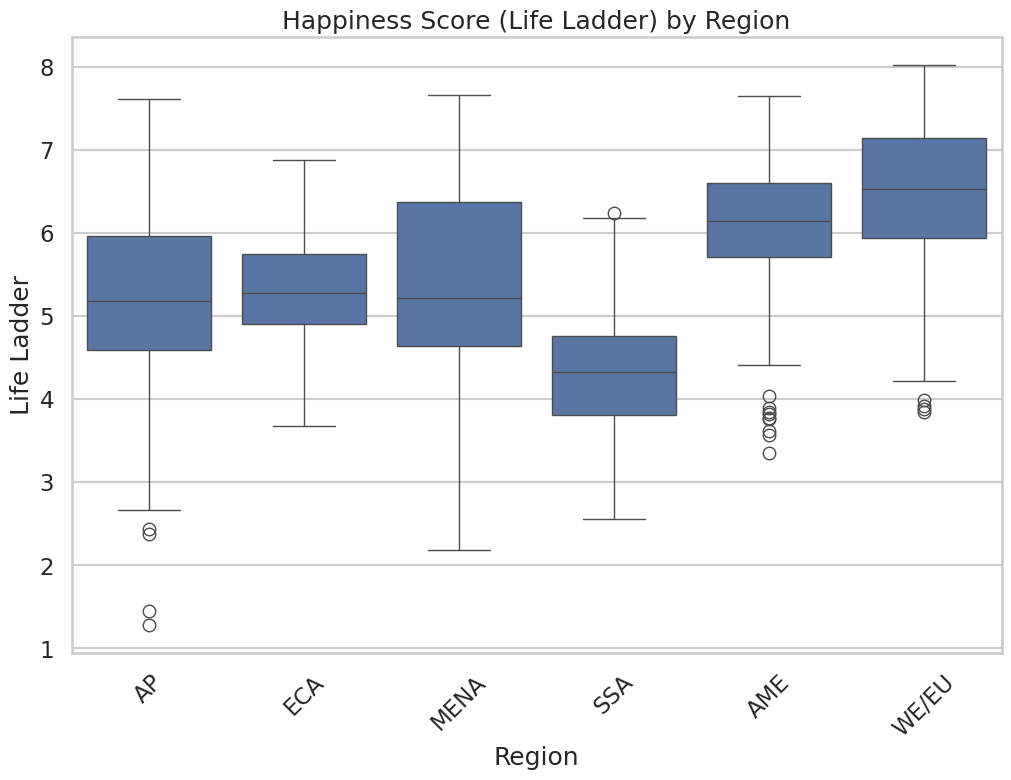

In [9]:
# Example merge: Merging world_happiness_report_2024 with GDP data on Country and Year
# Note: Ensure that the country names and years are in a compatible format.
df_happiness["Year"] = df_happiness["year"]  # create a duplicate for clarity if needed
merged_df = pd.merge(df_happiness, df_gdp, left_on=["Country", "Year"], right_on=["Country", "Year"], how="inner")

print("Merged dataset (Happiness and GDP) sample:")
print(merged_df.head())

# Boxplot of Happiness Score by Region (if you have a 'Region' column)
# For example, you might merge with CPI data (which has 'Region') or use HDR if available.
if "Region" in df_cpi.columns:
    merged_region = pd.merge(df_happiness, df_cpi[["Country", "Region"]], on="Country", how="left")
    plt.figure(figsize=(12, 8))
    sns.boxplot(x="Region", y="Life Ladder", data=merged_region)
    plt.title("Happiness Score (Life Ladder) by Region")
    plt.xlabel("Region")
    plt.ylabel("Life Ladder")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Region information not available in CPI data.")


# Summary

In this notebook, we loaded and explored the key datasets after cleaning. We checked for missing values, obtained descriptive statistics, and visualized the distributions of important variables. In subsequent notebooks, we will proceed with correlation analysis, multivariate analysis, and case studies.
